# Chapter 58: Sensor Embeddings and Augmentation

**When does a left-right swap help a wearable activity classifier, and what does it cost when the label is not updated with the swap?**

A swap is a hypothesis about symmetry. It is a free source of examples for rare handed classes when the label is updated with the geometry, and a source of wrong labels when it is not. Scores must come from people the model has not seen.

*Constructed data in which the mirror assumption holds exactly. The large gain at 0 and 1 people comes from a class that is nearly absent from the training set; with plenty of left-hand data the swap is close to neutral.*

## The experiment

Constructed wrist-sensor recordings: two three-axis units (left and right, mounted as mirror images), 32 Hz, 2 s windows with 50% overlap. Four activities: rest, walk (arms swing in antiphase), wave with the right hand and wave with the left hand. People differ in sensor gain and offset and in walking and waving style. A random forest on window summaries (mean, std, min, max, spectral peak per sensor, left-right correlation) is trained on 12 people, of whom only the number set by the control recorded the left-hand wave, and scored by macro F1 on 20 unseen people who recorded all four activities. The swap exchanges the two units and flips the lateral axis. It is applied three ways: not at all, with waving relabelled to the other hand, and with the original label kept.

In [1]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import GroupKFold, KFold

from kaggle_companion.activities._common import clean

SEED = 58
REPLICATES = 6                     # independent constructed cohorts; every estimate is their mean
TRAIN_SUBJECTS, TEST_SUBJECTS = 12, 20
RATE, WINDOW, STRIDE, RECORDING = 32, 64, 32, 320   # 32 Hz, 2 s windows with 50% overlap, 10 s recordings
NOISE = 0.6
CLASSES = ["rest", "walk", "wave_right", "wave_left"]
MIRROR = {0: 0, 1: 1, 2: 3, 3: 2}  # what a left-right swap does to each label: waving with one hand becomes waving with the other


def new_subject(rng):
    """Per-person differences: sensor gains and offsets, walking and waving style."""
    return {"gain": np.exp(rng.normal(0, 0.2, 2)), "bias": rng.normal(0, 0.4, (2, 3)), "swing": rng.uniform(1.0, 2.0),
            "step_hz": rng.uniform(1.6, 2.4), "phase": rng.uniform(0, 6.28), "wave": rng.uniform(0.5, 1.6), "wave_hz": rng.uniform(1.5, 3.0)}


def recording(activity, subject, rng):
    """(time, sensor, axis) readings. Sensor 0 is the left wrist, 1 the right; axes are lateral x, forward y, vertical z.
    The two wrist units are mounted as mirror images, so a left-hand wave has the opposite lateral sign to a right-hand wave."""
    t = np.arange(RECORDING) / RATE
    x = np.zeros((RECORDING, 2, 3))
    if activity == 1:                                    # walk: arms swing forward and back in antiphase
        a, f, ph = subject["swing"], subject["step_hz"], subject["phase"]
        x[:, 0, 1] = a * np.sin(2 * np.pi * f * t + ph)
        x[:, 1, 1] = a * np.sin(2 * np.pi * f * t + ph + np.pi)
        x[:, :, 2] = (0.3 * a * np.sin(4 * np.pi * f * t + 0.5))[:, None]
    if activity in (2, 3):                               # wave: sideways oscillation with the arm raised to the side
        sensor, sign = (1, 1.0) if activity == 2 else (0, -1.0)
        x[:, sensor, 0] = sign * (subject["wave"] * np.sin(2 * np.pi * subject["wave_hz"] * t) + 0.8)
    return x * subject["gain"][None, :, None] + subject["bias"][None] + rng.normal(0, NOISE, x.shape)


def cohort(subjects, left_wave_subjects, rng):
    """Windows, labels and subject ids. Only the first `left_wave_subjects` people recorded the left-hand wave."""
    windows, labels, owner = [], [], []
    for i in range(subjects):
        person = new_subject(rng)
        for activity in range(4):
            if activity == 3 and i >= left_wave_subjects:
                continue
            x = recording(activity, person, rng)
            for start in range(0, RECORDING - WINDOW + 1, STRIDE):
                windows.append(x[start:start + WINDOW])
                labels.append(activity)
                owner.append(i)
    return np.array(windows), np.array(labels), np.array(owner)


def swap_wrists(windows):
    """The augmentation: exchange the two sensors and flip the lateral axis, because the units are mirrored."""
    swapped = windows[:, :, ::-1, :].copy()
    swapped[..., 0] *= -1
    return swapped


def features(windows):
    """Per sensor and axis: mean, std, min, max; per sensor: strongest spectral peak; plus left-right forward correlation."""
    centered = windows - windows.mean(axis=1, keepdims=True)
    stats = np.stack([windows.mean(1), windows.std(1), windows.min(1), windows.max(1)], axis=-1)       # (n, sensor, axis, 4)
    peak = np.abs(np.fft.rfft(centered, axis=1))[:, 1:].max(axis=(1, 3))                                # (n, sensor)
    a, b = centered[:, :, 0, 1], centered[:, :, 1, 1]
    corr = (a * b).sum(1) / np.sqrt((a ** 2).sum(1) * (b ** 2).sum(1))
    return np.column_stack([stats.reshape(len(windows), -1), peak, corr])


def forest():
    return RandomForestClassifier(60, random_state=0, n_jobs=1)


def macro_f1(y_true, y_pred, labels):
    return float(f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0))


def one_cohort(left_wave_subjects, replicate):
    rng = np.random.default_rng(SEED * 100 + replicate)
    W, y, owner = cohort(TRAIN_SUBJECTS, left_wave_subjects, rng)
    W_test, y_test, _ = cohort(TEST_SUBJECTS, TEST_SUBJECTS, rng)         # unseen people, every class recorded
    F, F_test = features(W), features(W_test)
    out = {}
    for policy in ("none", "swap_relabel", "swap_keep_labels"):
        if policy == "none":
            F_fit, y_fit = F, y
        else:
            relabel = np.array([MIRROR[k] for k in y]) if policy == "swap_relabel" else y   # the wrong version keeps the old label
            F_fit, y_fit = np.vstack([F, features(swap_wrists(W))]), np.concatenate([y, relabel])
        pred = forest().fit(F_fit, y_fit).predict(F_test)
        out[policy] = {"macro_f1": macro_f1(y_test, pred, [0, 1, 2, 3]), "left_wave_f1": macro_f1(y_test, pred, [3])}
    # Two ways to estimate the unaugmented model from the training people alone, over the classes present in training.
    seen = sorted(set(y))
    window_cv, subject_cv = np.zeros(len(y), dtype=int), np.zeros(len(y), dtype=int)
    for fit, held in KFold(3, shuffle=True, random_state=0).split(F):
        window_cv[held] = forest().fit(F[fit], y[fit]).predict(F[held])
    for fit, held in GroupKFold(3).split(F, y, owner):
        subject_cv[held] = forest().fit(F[fit], y[fit]).predict(F[held])
    out["window_cv"], out["subject_cv"] = macro_f1(y, window_cv, seen), macro_f1(y, subject_cv, seen)
    return out


def run(left_wave_subjects):
    sets = [one_cohort(left_wave_subjects, i) for i in range(REPLICATES)]
    mean = lambda f: float(np.mean([f(s) for s in sets]))
    policies = {p: {"macro_f1": mean(lambda s: s[p]["macro_f1"]), "left_wave_f1": mean(lambda s: s[p]["left_wave_f1"]),
                    "per_cohort": [s[p]["macro_f1"] for s in sets]} for p in ("none", "swap_relabel", "swap_keep_labels")}
    return clean({"left_wave_subjects": left_wave_subjects, "policies": policies,
                  "window_cv": mean(lambda s: s["window_cv"]), "subject_cv": mean(lambda s: s["subject_cv"]),
                  "replicates": REPLICATES, "train_subjects": TRAIN_SUBJECTS, "test_subjects": TEST_SUBJECTS})


## Measure it across the control

The control is **training people who recorded the left-hand wave (of 12)**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch58 import explain

VALUES = [0, 1, 3, 12]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                                       0      1      3     12
No augmentation                    0.650  0.900  0.940  0.956
Swap, relabelled                   0.954  0.966  0.960  0.959
Swap, label kept                   0.643  0.651  0.684  0.748
Left-wave F1, relabelled swap      0.952  0.962  0.955  0.957
Window-level CV (no augmentation)  0.990  0.987  0.989  0.980


## Look at it

The figure shows the default setting, training people who recorded the left-hand wave (of 12) = 1.

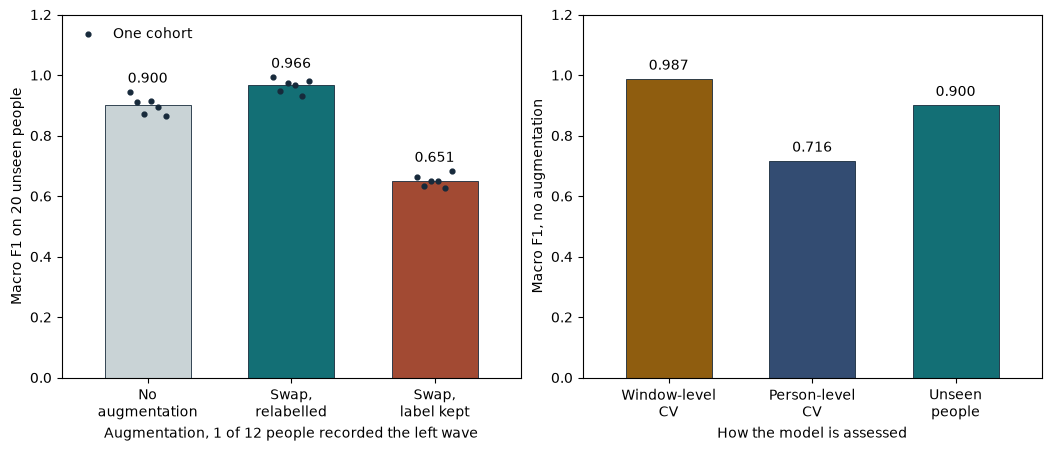

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch58 import draw, NCOLS, HEIGHT

DEFAULT = 1
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

When 1 of 12 training people recorded the left-hand wave, the model with no augmentation scores a macro F1 of 0.900 on unseen people and the relabelled swap 0.966, so 0.966 - 0.900 = 0.066 is the gain (left-wave F1 0.799 to 0.962). The swap that keeps the label scores 0.651, 0.900 - 0.651 = 0.249 below no augmentation. Window-level cross-validation on the training people reports 0.987 and person-level 0.716, against 0.900 on unseen people.

- Gain from the relabelled swap: 0.966 - 0.900 = +0.066.
- Cost of keeping the label: 0.651 - 0.900 = -0.249.
- Left-wave F1 with the relabelled swap: 0.962, without augmentation 0.799.
- Window-level CV minus unseen people: 0.987 - 0.900 = +0.087.

## Apply this to your competition

- Write down the sensor order, axis meaning and which labels depend on side before choosing any symmetry transform.
- Apply the swap together with the matching label change, or disable it for classes whose label does not survive the swap.
- Score each augmentation alone on people the model has never seen, and keep the no-augmentation model as the comparison.
- Split by person or recording before cutting overlapping windows, and expect a window-level or in-pool estimate to be higher than the unseen-person score.

Book location: Chapter 58, Keep Assessment Subjects Independent.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)